<a href="https://colab.research.google.com/github/RIYORIALDY/Optimization-from-Scratch/blob/main/ML_Optimization_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. IMPORT LIBRARY DAN DOWNLOAD DATA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Download dataset
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

df = pd.read_csv('Telco-Customer-Churn.csv')
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [ ]:
# 2. PREPROCESSING DATA
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

X = df[numerical_features].values
y = (df['Churn'] == 'Yes').astype(int).values  # Convert Yes/No to 1/0

# Manual stratified train_test_split
def my_train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    np.random.shuffle(idx0)
    np.random.shuffle(idx1)
    n0_test = int(len(idx0) * test_size)
    n1_test = int(len(idx1) * test_size)
    test_idx = np.concatenate([idx0[:n0_test], idx1[:n1_test]])
    train_idx = np.concatenate([idx0[n0_test:], idx1[n1_test:]])
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = my_train_test_split(X, y, test_size=0.2, random_state=42)

# Manual standardisasi
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [ ]:
# 3. LINEAR REGRESSION (Batch GD)
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            loss = np.mean((y_pred - y) ** 2)
            self.losses.append(loss)
            dw = (2/n_samples) * np.dot(X.T, (y_pred - y))
            db = (2/n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            if (i+1) % 100 == 0:
                print(f"Linear GD iter {i+1}: loss={loss:.4f}")

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        return 1 - (ss_residual / ss_total)

In [ ]:
# 4. LOGISTIC REGRESSION (Batch GD)
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.n_iterations):
            linear_pred = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_pred)
            epsilon = 1e-15
            y_pred = np.clip(y_pred, epsilon, 1-epsilon)
            loss = -np.mean(y * np.log(y_pred) + (1-y) * np.log(1-y_pred))
            self.losses.append(loss)
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            if (i+1) % 100 == 0:
                print(f"Logistic GD iter {i+1}: loss={loss:.4f}")

    def predict_proba(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_pred)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
# 5. LOGISTIC REGRESSION SGD
class LogisticRegressionSGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            epoch_loss = 0
            for idx in indices:
                xi = X[idx]
                yi = y[idx]
                linear_pred = np.dot(xi, self.weights) + self.bias
                y_pred = self.sigmoid(linear_pred)
                epsilon = 1e-15
                y_pred = np.clip(y_pred, epsilon, 1-epsilon)
                sample_loss = -(yi*np.log(y_pred) + (1-yi)*np.log(1-y_pred))
                epoch_loss += sample_loss
                dw = xi * (y_pred - yi)
                db = y_pred - yi
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            avg_loss = epoch_loss / n_samples
            self.losses.append(avg_loss)
            if (i+1) % 100 == 0:
                print(f"Logistic SGD iter {i+1}: loss={avg_loss:.4f}")

    def predict_proba(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_pred)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
# 6. TRAINING MODELS
print("\nTraining Linear Regression:")
lr_model = LinearRegressionGD(learning_rate=0.01, n_iterations=500)
lr_model.fit(X_train_scaled, y_train)
print(f"Linear R2 (Train): {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Linear R2 (Test): {lr_model.score(X_test_scaled, y_test):.4f}")

print("\nTraining Logistic Regression (Batch GD):")
log_model_batch = LogisticRegressionGD(learning_rate=0.1, n_iterations=500)
log_model_batch.fit(X_train_scaled, y_train)
print(f"Logistic BatchGD Acc (Train): {log_model_batch.accuracy(X_train_scaled, y_train):.4f}")
print(f"Logistic BatchGD Acc (Test): {log_model_batch.accuracy(X_test_scaled, y_test):.4f}")

print("\nTraining Logistic Regression (SGD):")
log_model_sgd = LogisticRegressionSGD(learning_rate=0.01, n_iterations=500)
log_model_sgd.fit(X_train_scaled, y_train)
print(f"Logistic SGD Acc (Train): {log_model_sgd.accuracy(X_train_scaled, y_train):.4f}")
print(f"Logistic SGD Acc (Test): {log_model_sgd.accuracy(X_test_scaled, y_test):.4f}")


Training Linear Regression:
Linear GD iter 100: loss=0.1553
Linear GD iter 200: loss=0.1521
Linear GD iter 300: loss=0.1518
Linear GD iter 400: loss=0.1516
Linear GD iter 500: loss=0.1515
Linear R2 (Train): 0.2233
Linear R2 (Test): 0.2148

Training Logistic Regression (Batch GD):
Logistic GD iter 100: loss=0.4749
Logistic GD iter 200: loss=0.4590
Logistic GD iter 300: loss=0.4557
Logistic GD iter 400: loss=0.4547
Logistic GD iter 500: loss=0.4543
Logistic BatchGD Acc (Train): 0.7837
Logistic BatchGD Acc (Test): 0.7925

Training Logistic Regression (SGD):
Logistic SGD iter 100: loss=0.4542
Logistic SGD iter 200: loss=0.4548
Logistic SGD iter 300: loss=0.4542
Logistic SGD iter 400: loss=0.4546
Logistic SGD iter 500: loss=0.4543
Logistic SGD Acc (Train): 0.7834
Logistic SGD Acc (Test): 0.7953


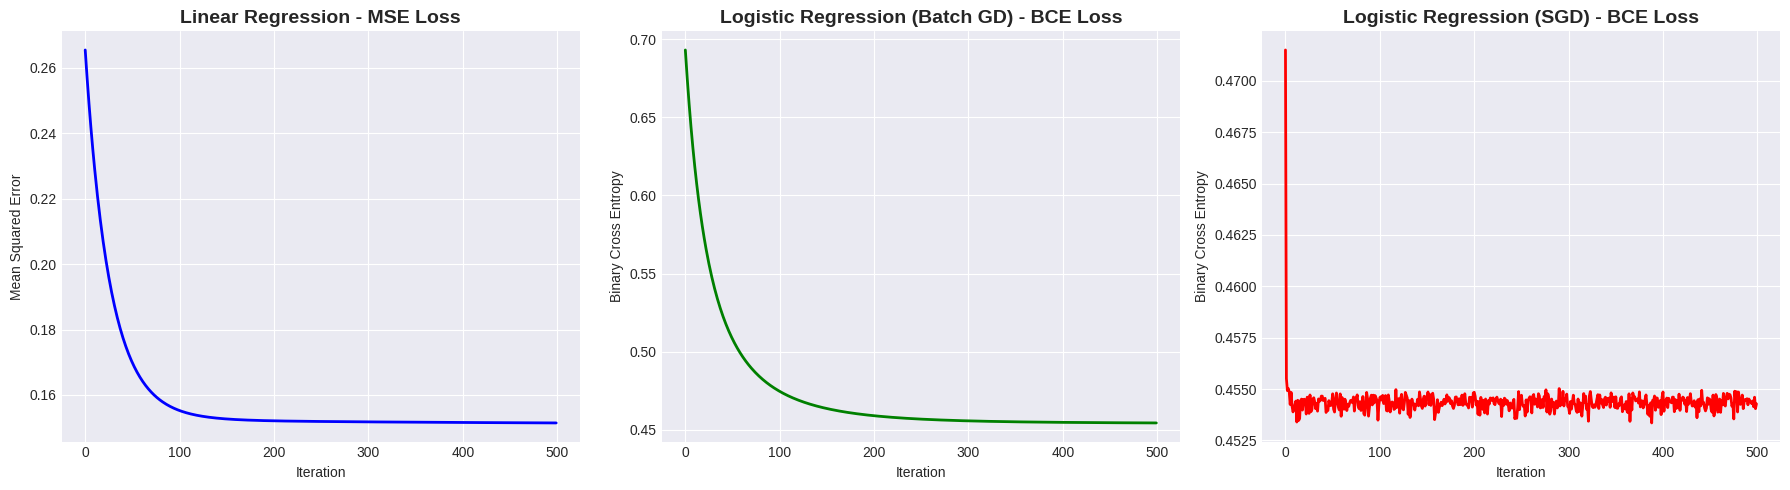

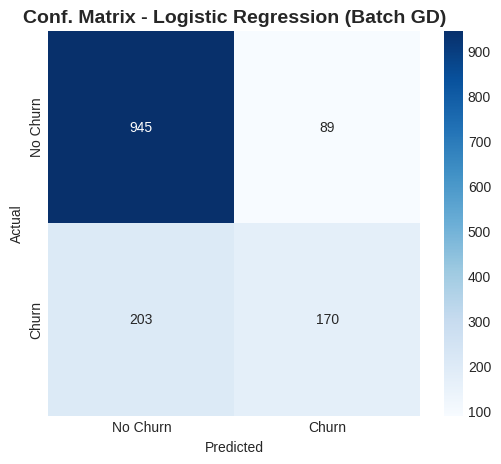

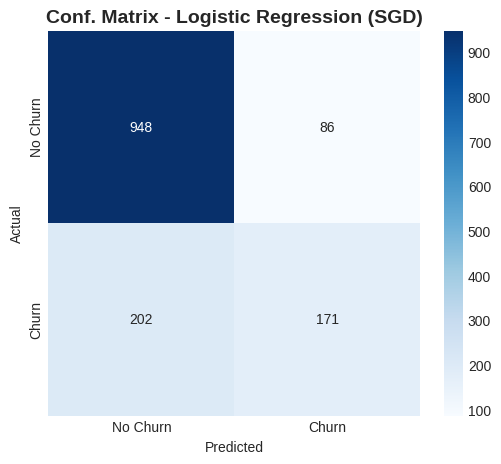

In [ ]:
# 7. VISUALISASI HASIL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(lr_model.losses, color='blue', linewidth=2)
axes[0].set_title('Linear Regression - MSE Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Mean Squared Error')
axes[1].plot(log_model_batch.losses, color='green', linewidth=2)
axes[1].set_title('Logistic Regression (Batch GD) - BCE Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Binary Cross Entropy')
axes[2].plot(log_model_sgd.losses, color='red', linewidth=2)
axes[2].set_title('Logistic Regression (SGD) - BCE Loss', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Binary Cross Entropy')
plt.tight_layout()
plt.show()

# Confusion Matrix Plot
def plot_confusion_matrix(y_true, y_pred, title):
    cm = np.zeros((2,2), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        cm[yt, yp] += 1
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()

y_pred_batch = log_model_batch.predict(X_test_scaled)
plot_confusion_matrix(y_test, y_pred_batch, 'Conf. Matrix - Logistic Regression (Batch GD)')
y_pred_sgd = log_model_sgd.predict(X_test_scaled)
plot_confusion_matrix(y_test, y_pred_sgd, 'Conf. Matrix - Logistic Regression (SGD)')